# Fine-Tuned Model Evaluation (v6 - Augmented Data)
UAV verisiyle fine-tune edilmiş Trajectron++ modelinin test verisindeki prediction'larını görselleştirir.

**Base**: ETH 100-epoch → Fine-tune: kl_min=2.0, kl_crossover=-1000 (full KL), 6x augmented data, epoch 30

**Note:** For comprehensive analysis including prediction ranking, see `prediction_analysis.ipynb`

In [16]:
import sys
import os
import json
import torch
import numpy as np
import dill
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

sys.path.append('../../trajectron')
from model.model_registrar import ModelRegistrar
from model.trajectron import Trajectron
from utils import prediction_output_to_trajectories

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

In [17]:
# --- Config ---
MODEL_DIR = 'models/models_09_Mar_2026_16_10_23_uav_ft_v6_aug'
CHECKPOINT_EPOCH = 30
TEST_DATA = 'processed/uav_finetune_test.pkl'
DEVICE = 'cpu'

# Load config
with open(os.path.join(MODEL_DIR, 'config.json'), 'r') as f:
    hyperparams = json.load(f)

# Load test data
with open(TEST_DATA, 'rb') as f:
    eval_env = dill.load(f, encoding='latin1')

print('Test scenes:', len(eval_env.scenes))
for s in eval_env.scenes:
    print(f'  {s.name}: {s.timesteps} timesteps, {len(s.nodes)} nodes')

Test scenes: 6
  IMG_5495: 62 timesteps, 1 nodes
  IMG_5497_seg3: 148 timesteps, 1 nodes
  IMG_5499_seg0: 92 timesteps, 1 nodes
  IMG_5500_seg0: 51 timesteps, 1 nodes
  IMG_5486_seg0: 27 timesteps, 1 nodes
  IMG_5494_seg1: 16 timesteps, 1 nodes


In [18]:
# --- Load Model ---
model_registrar = ModelRegistrar(MODEL_DIR, DEVICE)

trajectron = Trajectron(model_registrar, hyperparams, None, DEVICE)
trajectron.set_environment(eval_env)
trajectron.set_annealing_params()

# Load fine-tuned weights
cp_path = os.path.join(MODEL_DIR, f'model_registrar-{CHECKPOINT_EPOCH}.pt')
checkpoint_state = torch.load(cp_path, map_location=DEVICE)
model_registrar.model_dict.load_state_dict(checkpoint_state.state_dict())
model_registrar.eval()  # inference mode

print(f'Loaded fine-tuned model (epoch {CHECKPOINT_EPOCH})')

Loaded fine-tuned model (epoch 30)


/var/folders/qk/fhmvz1wd1s719d139j5224300000gn/T/ipykernel_44074/2652862955.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint_state = torch.load(cp_path, map_l

In [19]:
# --- Predict on all test scenes ---
ph = hyperparams['prediction_horizon']  # 12
max_hl = hyperparams['maximum_history_length']  # 7
num_samples = 20

all_results = []

with torch.no_grad():
    for scene in eval_env.scenes:
        # Pick multiple timesteps spread across the scene
        valid_range = range(max_hl, scene.timesteps - ph)
        if len(valid_range) < 1:
            continue
        
        # Sample evenly spaced timesteps
        n_samples_ts = min(5, len(valid_range))
        timesteps = np.linspace(valid_range.start, valid_range.stop - 1, n_samples_ts, dtype=int)
        
        for ts in timesteps:
            predictions = trajectron.predict(
                scene, np.array([ts]), ph,
                num_samples=num_samples,
                min_future_timesteps=ph,
                min_history_timesteps=1,
                z_mode=False, gmm_mode=False,
                full_dist=False
            )
            
            if predictions:
                pred_dict, hist_dict, fut_dict = prediction_output_to_trajectories(
                    predictions, scene.dt, max_hl, ph
                )
                if ts in pred_dict and len(pred_dict[ts]) > 0:
                    all_results.append({
                        'scene': scene.name,
                        'timestep': ts,
                        'predictions': pred_dict[ts],
                        'histories': hist_dict[ts],
                        'futures': fut_dict[ts],
                    })

print(f'{len(all_results)} prediction noktasi uretildi')

25 prediction noktasi uretildi


/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(
/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(
/Users/simayyalcin/miniconda3/envs/trajectron/lib/python3.8/site-packages/torch/distributions/distribution.py:55: UserWarning: <class 'model.components.gmm2d.GMM2D'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn

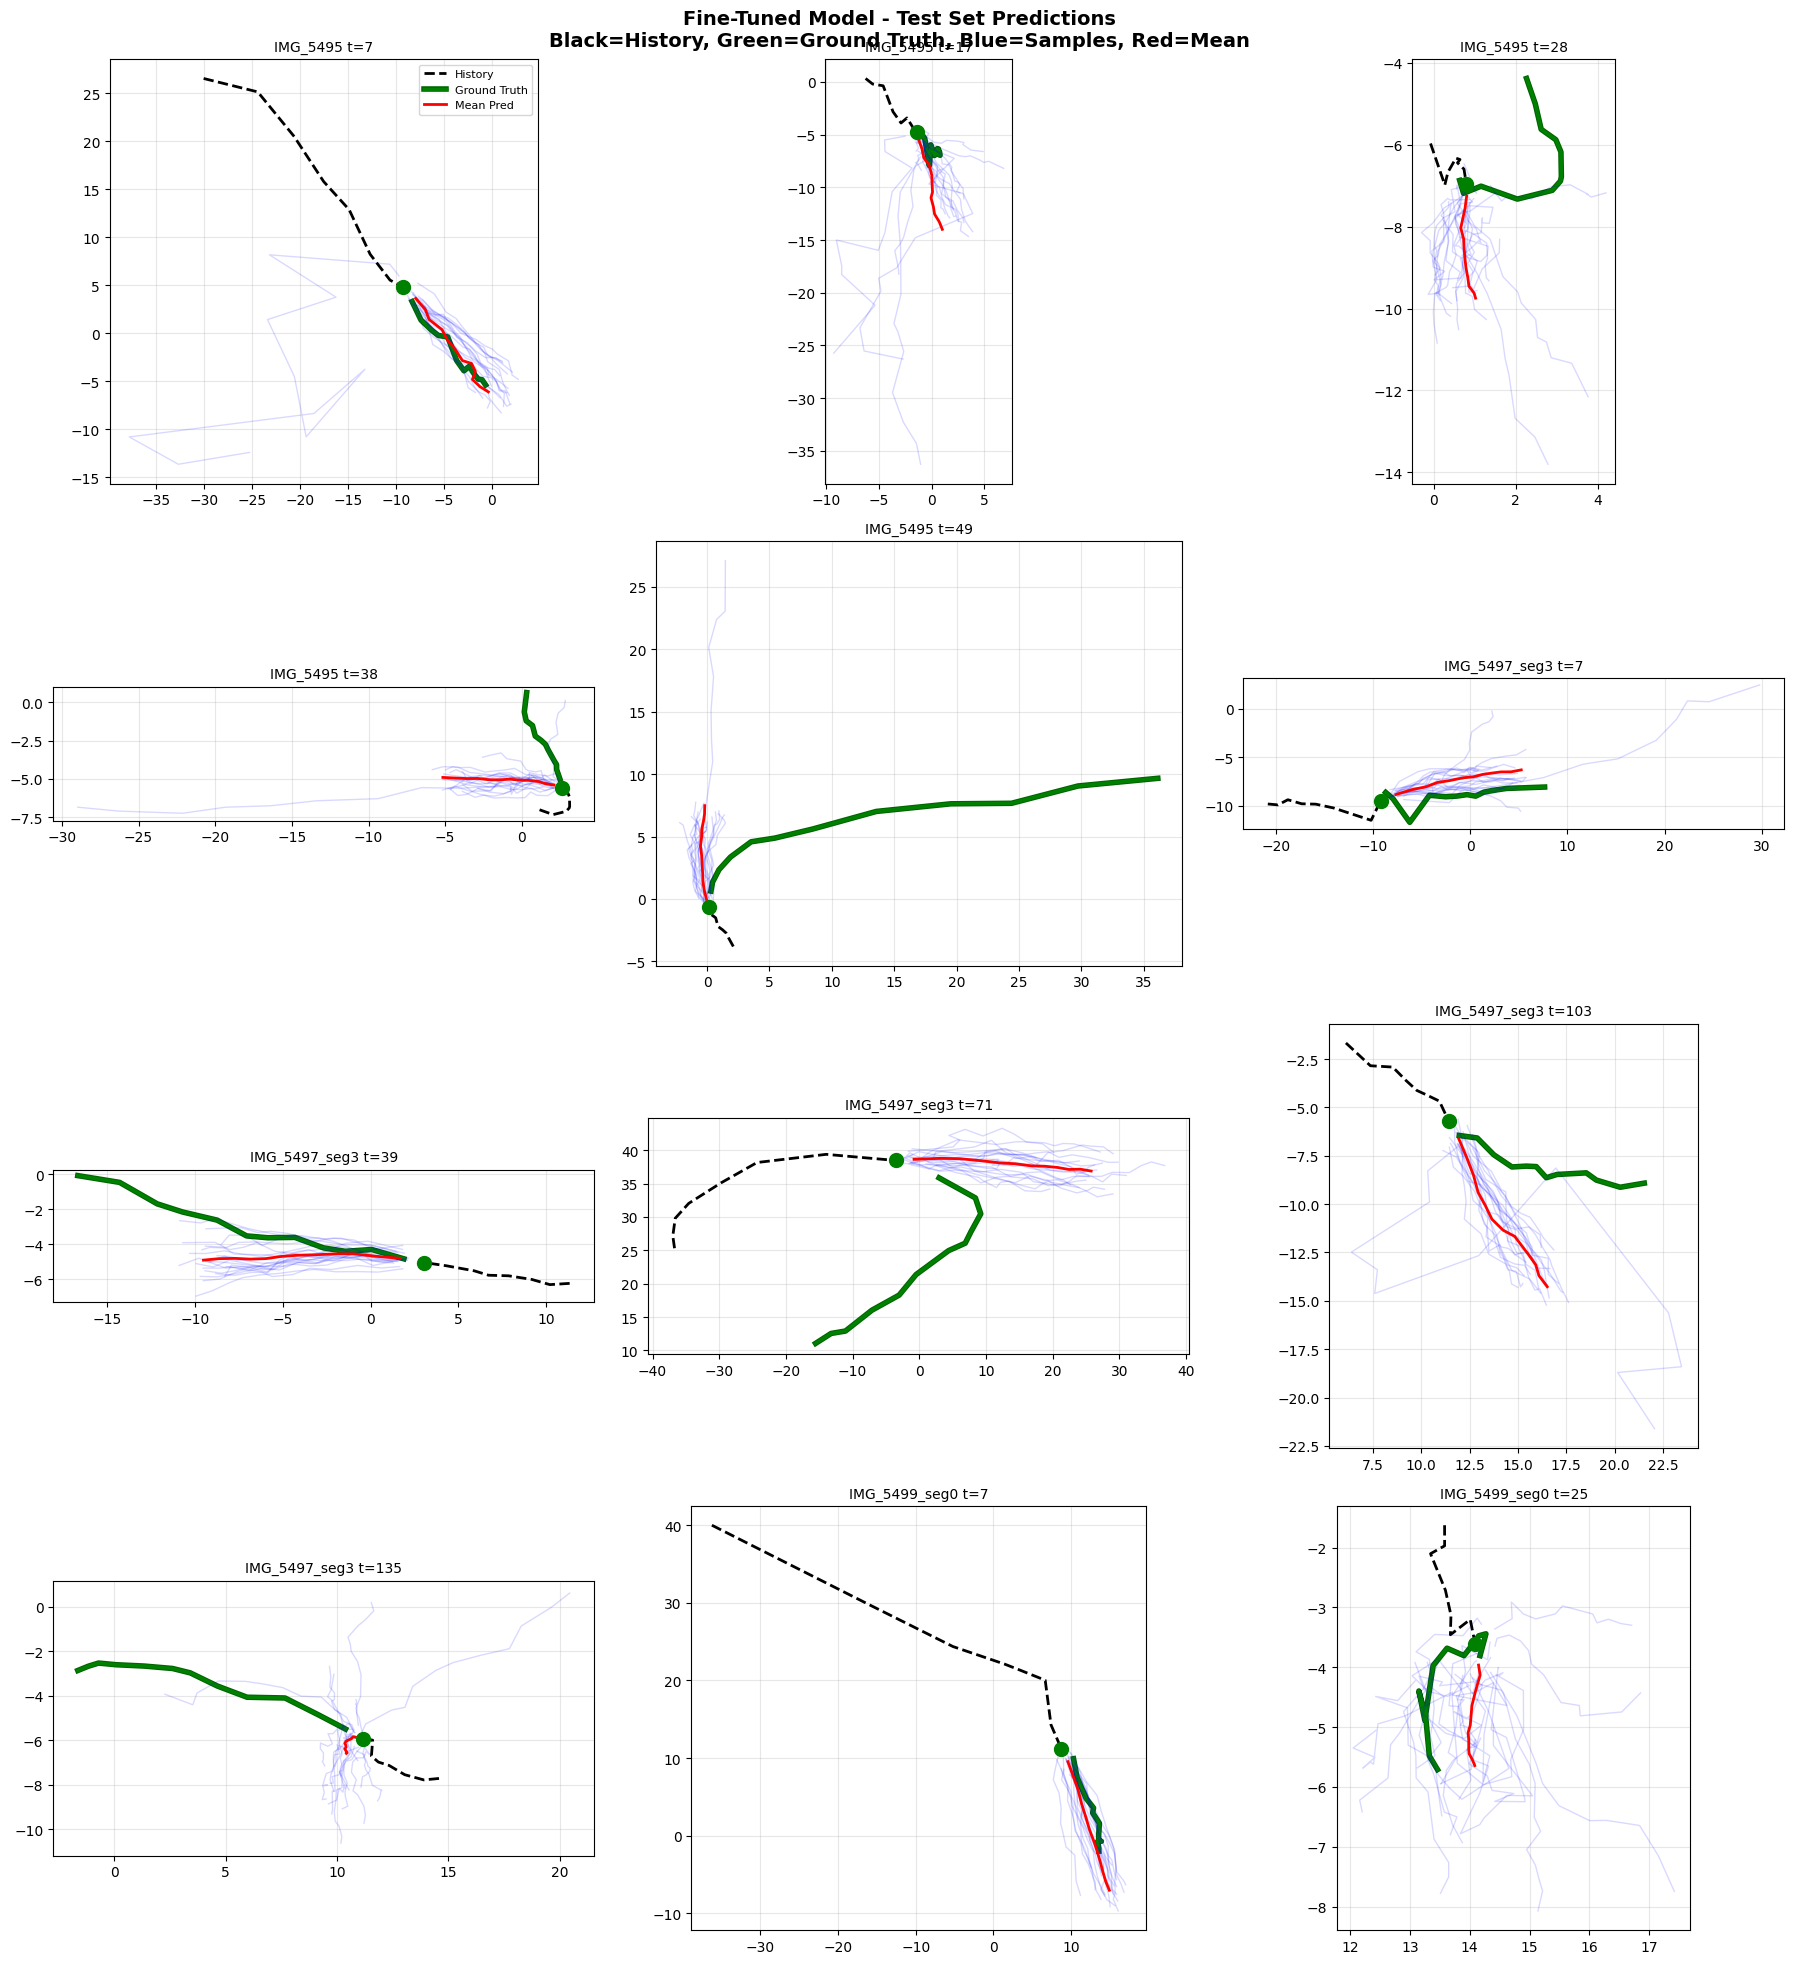

In [20]:
# --- Visualization ---
n_plots = min(len(all_results), 12)
cols = 3
rows = (n_plots + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
if rows == 1:
    axes = axes.reshape(1, -1)

for idx in range(n_plots):
    ax = axes[idx // cols, idx % cols]
    r = all_results[idx]
    
    for node in r['predictions']:
        history = r['histories'][node]
        future = r['futures'][node]
        preds = r['predictions'][node]  # (1, num_samples, ph, 2)
        
        # History (black dashed)
        ax.plot(history[:, 0], history[:, 1], 'k--', linewidth=2, label='History')
        
        # Ground truth future (green solid)
        ax.plot(future[:, 0], future[:, 1], 'g-', linewidth=2.5,
                path_effects=[pe.Stroke(linewidth=4, foreground='darkgreen'), pe.Normal()],
                label='Ground Truth')
        
        # Predicted samples (blue, transparent)
        for s in range(preds.shape[1]):
            ax.plot(preds[0, s, :, 0], preds[0, s, :, 1],
                    'b-', alpha=0.15, linewidth=1)
        
        # Mean prediction (red)
        mean_pred = preds[0].mean(axis=0)
        ax.plot(mean_pred[:, 0], mean_pred[:, 1], 'r-', linewidth=2, label='Mean Pred')
        
        # Current position (green dot)
        ax.plot(history[-1, 0], history[-1, 1], 'go', markersize=10, zorder=5)
    
    ax.set_title(f"{r['scene']} t={r['timestep']}", fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide empty subplots
for idx in range(n_plots, rows * cols):
    axes[idx // cols, idx % cols].set_visible(False)

plt.suptitle('Fine-Tuned Model - Test Set Predictions\n'
             'Black=History, Green=Ground Truth, Blue=Samples, Red=Mean',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# --- ADE / FDE Metrics ---
ade_list = []
fde_list = []

for r in all_results:
    for node in r['predictions']:
        preds = r['predictions'][node]  # (1, num_samples, ph, 2)
        future = r['futures'][node]     # (ph, 2)
        
        if len(future) < ph:
            continue
        
        # Best of N: pick the sample closest to GT
        for s in range(preds.shape[1]):
            pred_traj = preds[0, s, :len(future), :]
            errors = np.sqrt(((pred_traj - future) ** 2).sum(axis=1))
            ade_list.append(errors.mean())
            fde_list.append(errors[-1])

ade = np.array(ade_list)
fde = np.array(fde_list)

print('=== Test Set Metrics ===')
print(f'ADE (all samples):  mean={ade.mean():.2f}, median={np.median(ade):.2f}')
print(f'FDE (all samples):  mean={fde.mean():.2f}, median={np.median(fde):.2f}')

# Best-of-20
best_ade = []
best_fde = []
for r in all_results:
    for node in r['predictions']:
        preds = r['predictions'][node]
        future = r['futures'][node]
        if len(future) < ph:
            continue
        sample_ades = []
        sample_fdes = []
        for s in range(preds.shape[1]):
            pred_traj = preds[0, s, :len(future), :]
            errors = np.sqrt(((pred_traj - future) ** 2).sum(axis=1))
            sample_ades.append(errors.mean())
            sample_fdes.append(errors[-1])
        best_ade.append(min(sample_ades))
        best_fde.append(min(sample_fdes))

print(f'\nBest-of-{num_samples} ADE: mean={np.mean(best_ade):.2f}')
print(f'Best-of-{num_samples} FDE: mean={np.mean(best_fde):.2f}')

=== Test Set Metrics ===
ADE (all samples):  mean=6.94, median=4.29
FDE (all samples):  mean=14.27, median=9.56

Best-of-20 ADE: mean=5.08
Best-of-20 FDE: mean=10.71


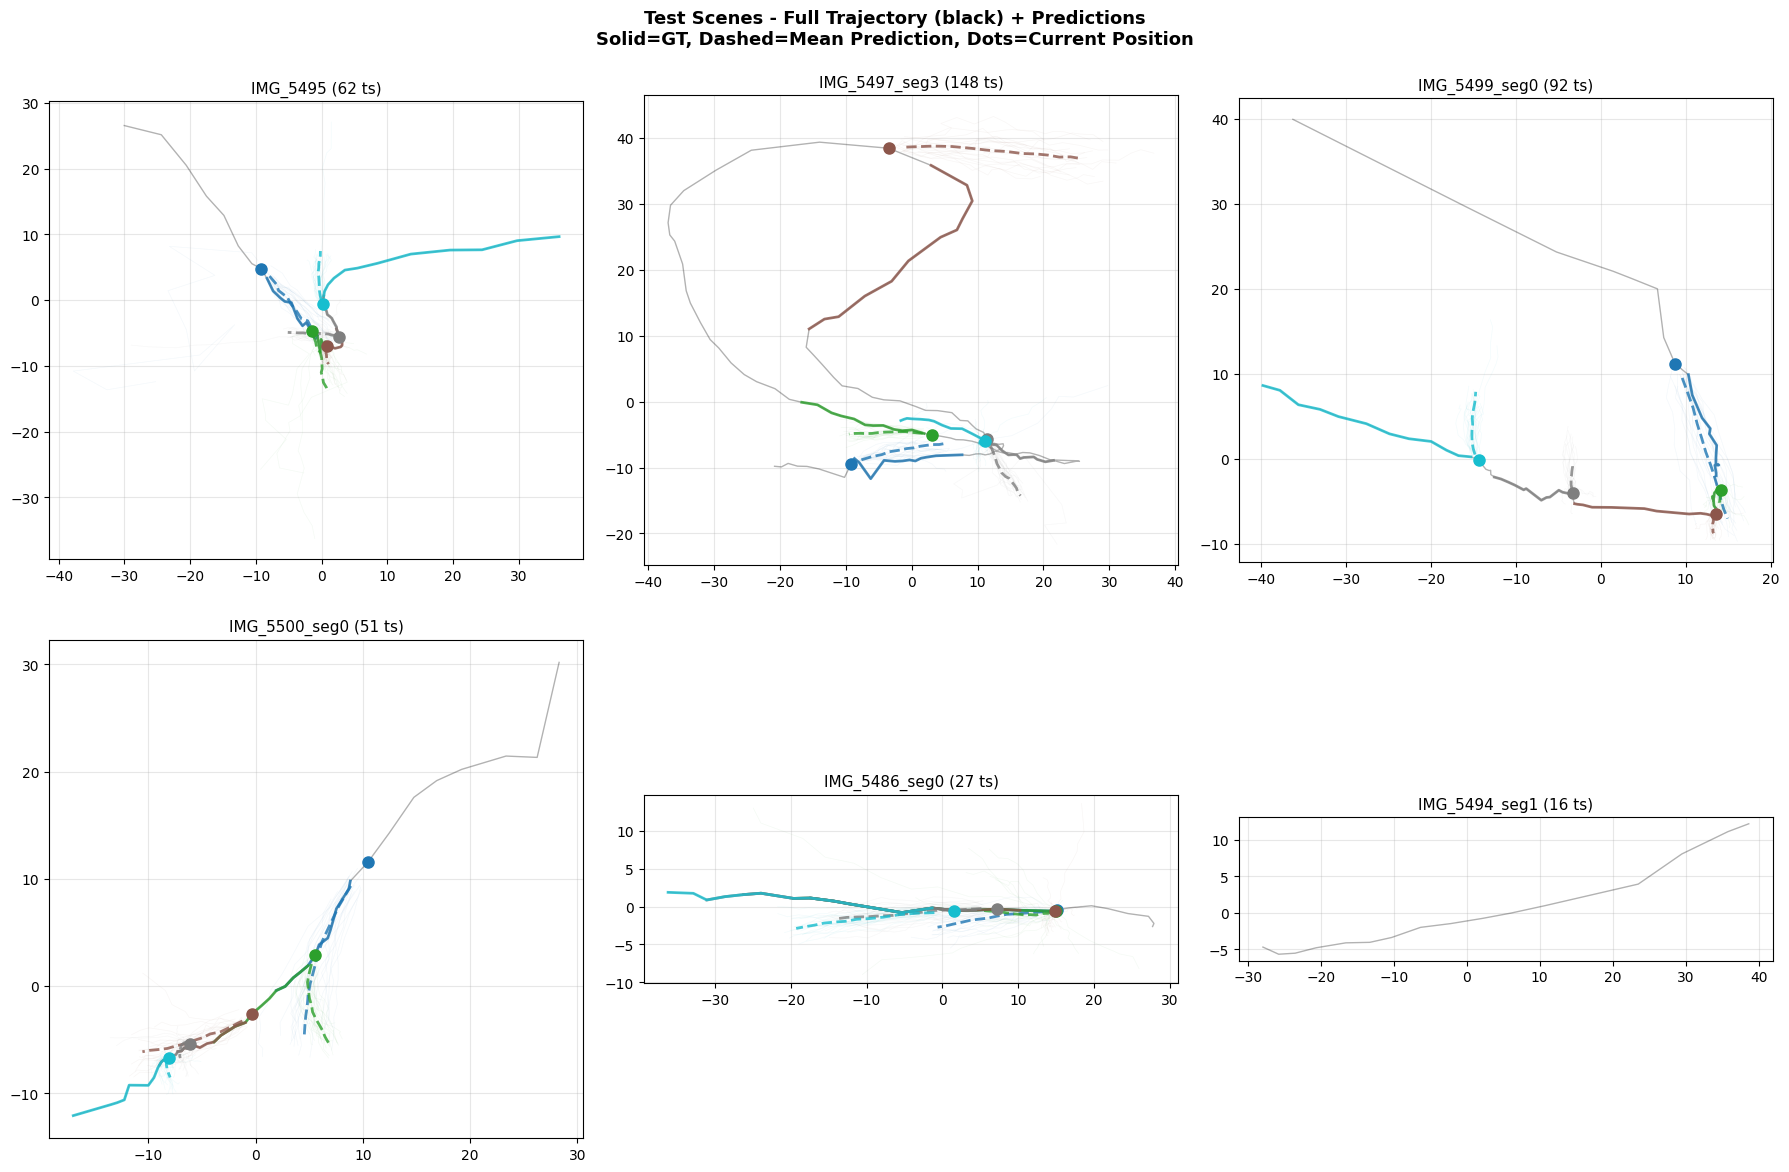

In [22]:
# --- Scene bazli detayli gorsellestirme ---
# Her test scene icin en uzun trajectory'yi goster
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for si, scene in enumerate(eval_env.scenes):
    if si >= 6:
        break
    ax = axes[si]
    
    # Scene'deki tum node'larin tam trajectory'sini ciz
    for node in scene.nodes:
        data = node.data.data
        pos_x = data[:, 0]
        pos_y = data[:, 1]
        ax.plot(pos_x, pos_y, 'k-', alpha=0.3, linewidth=1, label='Full trajectory')
    
    # Bu scene'deki prediction sonuclarini goster
    scene_results = [r for r in all_results if r['scene'] == scene.name]
    
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(scene_results), 1)))
    for ri, r in enumerate(scene_results):
        for node in r['predictions']:
            history = r['histories'][node]
            future = r['futures'][node]
            preds = r['predictions'][node]
            
            ax.plot(history[-1, 0], history[-1, 1], 'o',
                    color=colors[ri], markersize=8, zorder=5)
            
            # GT
            ax.plot(future[:, 0], future[:, 1], '-',
                    color=colors[ri], linewidth=2, alpha=0.8)
            
            # Mean prediction
            mean_pred = preds[0].mean(axis=0)
            ax.plot(mean_pred[:, 0], mean_pred[:, 1], '--',
                    color=colors[ri], linewidth=2, alpha=0.8)
            
            # Prediction spread (min/max hull)
            for s in range(preds.shape[1]):
                ax.plot(preds[0, s, :, 0], preds[0, s, :, 1],
                        '-', color=colors[ri], alpha=0.05, linewidth=0.5)
    
    ax.set_title(f'{scene.name} ({scene.timesteps} ts)', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Test Scenes - Full Trajectory (black) + Predictions\n'
             'Solid=GT, Dashed=Mean Prediction, Dots=Current Position',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()